# 03. Modelo Predictivo 02 - La respuesta llegara a tiempo?

## Librerias

In [4]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, mean_absolute_error, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
    

## Carga del dataset limpio

In [5]:
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_21860\1742754170.py:1: SyntaxWarning: invalid escape sequence '\d'
  dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


## Modelos a realizar

#### Modelo Random Forest Baseline

In [17]:
def entrenar_rf_baseline_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(
            random_state=random_state,
            class_weight='balanced'
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [None, 20],
        'clf__min_samples_split': [2, 5],
        'clf__min_samples_leaf': [1, 2]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba))
    print("\nMejores parámetros:", grid.best_params_)

    return best_model, grid

De la misma forma que en el modelo anterior vamos a implementar un pipeline con Random Forest para resolver un problema de clasificacion, en este caso binaria, para ver si la respuesta emitida a la empresa sera a tiempo o no.

Por medio de esta funcion separamos las variables categoricas de las numericas, dividimos el conjunto de datos en entrenamiento y prueba, transforma las variables categorias mediante un OneHotEnconder mientras que las numericas pasan directamente al modelo. 

In [18]:
best_rf_baseline, grid_rf_baseline = entrenar_rf_baseline_timely(dt_quejas)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Matriz de confusión:
 [[  71   71]
 [  71 5419]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.50      0.50      0.50       142
         Yes       0.99      0.99      0.99      5490

    accuracy                           0.97      5632
   macro avg       0.74      0.74      0.74      5632
weighted avg       0.97      0.97      0.97      5632


Accuracy: 0.9747869318181818
ROC AUC: 0.8765848277277508

Mejores parámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}


El modelo de Random Forest muestra un rendimiento muy sólido en términos generales, con una accuracy del 97.4% y un ROC AUC de 0.87, lo que refleja una alta capacidad para distinguir entre respuestas a tiempo y no a tiempo. La clase mayoritaria ("Yes") es predicha con gran precisión y recall cercanos al 100%, lo que significa que el modelo prácticamente no falla al identificar los casos en los que la respuesta llega puntualmente.

No obstante, al analizar la clase minoritaria ("No"), el desempeño sigue siendo más limitado: el modelo logra detectar menos de la mitad de los casos (recall de 0.50), lo que implica que una parte importante de las respuestas tardías continúa clasificándose como puntuales. Este resultado es consecuencia directa del fuerte desbalance de clases, ya que la gran mayoría de las observaciones en el dataset corresponden a "Yes".

En resumen, el Random Forest constituye una base robusta y precisa para identificar respuestas a tiempo, pero presenta margen de mejora en la detección de los casos minoritarios. Ajustes adicionales como el uso de SMOTE, ponderación de clases o el ajuste del umbral de decisión podrían ayudar a mejorar la sensibilidad hacia los casos de "No", logrando un modelo más equilibrado.

#### Definimos la funcion para Random Forest + SMOTE + Hiperparametrizacion con GridSearchCV

In [15]:
def entrenar_modelo_gs_smote(X, y, labels=('No','Yes'), test_size=0.2, random_state=42):
    
    categorical_features = X.select_dtypes(include='object').columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=test_size, random_state=random_state
    )

    
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ],
        remainder='passthrough'
    )

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('classifier', RandomForestClassifier(random_state=random_state))
    ])

    param_grid = {
        'classifier__n_estimators': [300],
        'classifier__max_depth': [None, 20],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2],
        'classifier__max_features': ['sqrt'],
        'smote__k_neighbors': [5] 
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',      
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = None
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    if y_proba is not None:
        lb = LabelBinarizer()
        lb.fit(y_test)
        y_test_bin = lb.transform(y_test)
        
        if y_proba.shape[1] == 2:
            pos_index = list(labels).index('Yes') if 'Yes' in labels else 1
            auc = roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba[:, pos_index])
            print(f"ROC AUC (binario): {auc:.4f}")
        else:
            auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
            print(f"ROC AUC (OvR, macro): {auc:.4f}")
    else:
        print("ROC AUC: el clasificador no expone predict_proba().")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de confusión (test)')
    plt.xlabel('Predicción'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    print("\nDistribución de clases:")
    print("Train:\n", y_train.value_counts(normalize=True).round(3))
    print("\nTest:\n", y_test.value_counts(normalize=True).round(3))

    return best_model, grid



Dados los resultados obtenido con el modelo base, este nuevo pipeline emplea SMOTE para generar ejemplos sinteticos de la clase minoritaria para posteriomente aplicar Random Forest de cara a obtener un clasificador, para finalmente por medio de GridSearchCV se optimizan hiperparametros clave como profundidad, número de árboles, parámetros de división, etc.

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Matriz de confusión:
 [[  67   75]
 [  21 5469]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.76      0.47      0.58       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.98      5632
   macro avg       0.87      0.73      0.79      5632
weighted avg       0.98      0.98      0.98      5632


Métricas adicionales:
Accuracy: 0.9830
Precision (macro): 0.8739
Recall (macro): 0.7340
F1-score (macro): 0.7870
F1-score (weighted): 0.9810
ROC AUC (binario): 0.8826

 Mejores parámetros: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300, 'smote__k_neighbors': 5}
 Mejor F1-macro (CV): 0.8091


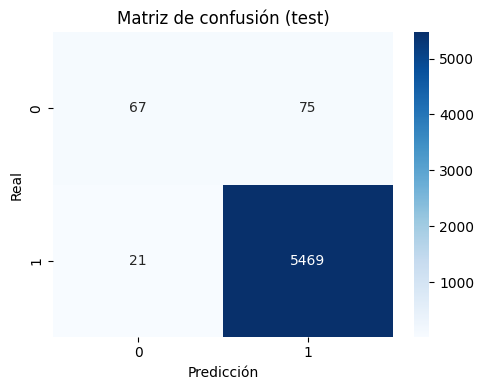


Distribución de clases:
Train:
 Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64

Test:
 Timely response?
Yes    0.975
No     0.025
Name: proportion, dtype: float64


In [16]:
y = dt_quejas['Timely response?']
X = dt_quejas.drop(columns=[
    'Timely response?', 'Complaint ID',
    'Date received', 'Date sent to company', 'ZIP code', 'Company'
]).copy()

X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

best_model_timely, grid_timely = entrenar_modelo_gs_smote(
    X, y, labels=('No','Yes')   
)


El modelo de Random Forest con SMOTE alcanzó una precisión global muy alta (≈ 98.3%), pero lo más relevante es que, además de clasificar correctamente la gran mayoría de respuestas “Yes” (a tiempo),además el modelo logra identificar casi la mitad de los casos "No" (recall = 0.47) con buena precisión (0.76). Esto significa que no predice al azar, sino que cuando detecta un “No” suele tener razón. Aunque todavía le cuesta detectar los retrasos, lo hace claramente mejor que si se limitara a favorecer la clase mayoritaria. Gracias a SMOTE, se consiguió un un equilibrio razonable entre ambas clases, alcanzando un F1-macro cercano a 0.80 y un AUC de aproximadamente 0.88, lo que muestra una buena capacidad para diferenciar entre respuestas a tiempo y tardías.

### Modelo con XGBoost

In [19]:
def entrenar_xgb_baseline_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=['No','Yes']))
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nMejores parámetros:", grid.best_params_)

    return best_model, grid


In [20]:
best_xgb_baseline, grid_xgb_baseline = entrenar_xgb_baseline_timely(dt_quejas)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  66   76]
 [   0 5490]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       1.00      0.46      0.63       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.99      0.73      0.81      5632
weighted avg       0.99      0.99      0.98      5632


Accuracy: 0.9865056818181818
ROC AUC: 0.9201403319736268

Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'clf__subsample': 0.8}


El modelo alcanzó una accuracy muy alta (98.6%) y un AUC de 0.92, lo que indica que diferencia bien entre respuestas a tiempo y tardías. Como ocurre en otros modelos, la clase mayoritaria (“Yes”) es predicha casi perfectamente (precision y recall ≈ 1.00). En cambio, la clase minoritaria (“No”) sigue siendo más difícil: el modelo acierta menos de la mitad de los casos de retraso (recall ≈ 0.46), aunque con una precesion casi perfecta.

En resumen, el XGBoost ofrece un rendimiento sólido y comparable al Random Forest con SMOTE, manteniendo una alta capacidad de clasificación global. Sin embargo, todavía presenta limitaciones a la hora de identificar los pocos casos de respuestas tardías, lo que refleja que el desbalance de clases sigue siendo un desafío incluso en modelos potentes como este.

### Modelo con XGBoost + SMOTE

In [21]:
def entrenar_xgb_smote_timely(dt_quejas_corr, random_state=42):

    y = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID',
        'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ])

    
    X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=random_state)),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',  
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
        'smote__k_neighbors': [3, 5]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred_num = best_model.predict(X_test)                 
    y_proba_yes = best_model.predict_proba(X_test)[:, 1]    

    
    inv_map = {0: 'No', 1: 'Yes'}
    y_pred = pd.Series(y_pred_num).map(inv_map)
    y_test_lbl = pd.Series(y_test).map(inv_map)

    
    print("Matriz de confusión:\n", confusion_matrix(y_test_lbl, y_pred, labels=['No','Yes']))
    print("\nReporte de clasificación:\n", classification_report(y_test_lbl, y_pred, labels=['No','Yes']))

    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test_lbl, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test_lbl, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test_lbl, y_pred, average='weighted'):.4f}")

    auc = roc_auc_score(y_test, y_proba_yes)
    print(f"ROC AUC (binario): {auc:.4f}")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test_lbl, y_pred, labels=['No','Yes']),
                annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title('Matriz de confusión (XGB + SMOTE)')
    plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    return best_model, grid

Fitting 5 folds for each of 64 candidates, totalling 320 fits


c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Matriz de confusión:
 [[  66   76]
 [   0 5490]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       1.00      0.46      0.63       142
         Yes       0.99      1.00      0.99      5490

    accuracy                           0.99      5632
   macro avg       0.99      0.73      0.81      5632
weighted avg       0.99      0.99      0.98      5632


Métricas adicionales:
Accuracy: 0.9865
Precision (macro): 0.9932
Recall (macro): 0.7324
F1-score (macro): 0.8139
F1-score (weighted): 0.9841
ROC AUC (binario): 0.9156

 Mejores parámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 500, 'clf__subsample': 0.8, 'smote__k_neighbors': 5}
 Mejor F1-macro (CV): 0.8294


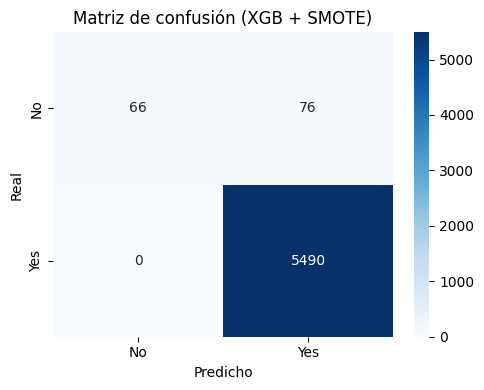

In [22]:
best_xgb_smote, grid_xgb_smote = entrenar_xgb_smote_timely(dt_quejas)


El modelo de XGBoost con SMOTE muestra un rendimiento global muy alto, con una accuracy cercana al 99% y un AUC de 0.92, lo que confirma su capacidad para distinguir entre respuestas a tiempo y retrasadas. La clase mayoritaria (“Yes”) sigue siendo predicha con gran precisión y recall prácticamente perfectos, asegurando que la gran mayoría de los casos sean clasificados correctamente como respuestas puntuales. Lo interesante está en la clase minoritaria (“No”), donde a pesar del fuerte desbalance de datos, el modelo consigue capturar una parte relevante de los retrasos. Aunque el recall es de alrededor de 0.46 (es decir, detecta casi la mitad de los casos tardíos), el hecho de que la precisión sea de 1.00 significa que cuando predice que habrá retraso, no se equivoca. Esto hace que el modelo sea muy confiable para detectar retrasos, incluso si todavía deja escapar una proporción considerable. El F1 para esta clase se mantiene en torno a 0.63, reflejando ese equilibrio entre sensibilidad limitada y gran precisión. En conjunto, el modelo logra un F1-macro de ≈ 0.81 y un AUC de 0.916, lo que indica que, tras aplicar SMOTE, se ha conseguido un mejor balance entre las dos clases. Dicho de forma simple: sigue prediciendo muy bien la mayoría de los casos de respuestas a tiempo y, aunque le cuesta abarcar todos los retrasos, ha mejorado en su detección respecto a configuraciones anteriores. Esto lo convierte en un modelo sólido para un escenario donde lo importante es no equivocarse cuando se señala un caso tardío.

#### Modelo con XGBoost + ajuste de pesos

In [23]:
def entrenar_xgb_weight_timely(dt_quejas_corr, threshold=0.5, random_state=42):
    y_str = dt_quejas_corr['Timely response?']
    X = dt_quejas_corr.drop(columns=[
        'Timely response?', 'Complaint ID', 'Date received', 'Date sent to company', 'ZIP code', 'Company'
    ]).copy()

    if 'Difference in days' in X.columns:
        X['Difference in days'] = pd.to_numeric(X['Difference in days'], errors='coerce').fillna(0)
    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train_str, y_test_str = train_test_split(
        X, y_str, stratify=y_str, test_size=0.2, random_state=random_state
    )

    map_y = {'No': 0, 'Yes': 1}
    y_train = y_train_str.map(map_y).astype(int)
    y_test  = y_test_str.map(map_y).astype(int)

    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    spw = (neg / pos) if pos > 0 else 1.0
    print(f"scale_pos_weight (train): {spw:.2f}  |  Positivos: {pos}  Negativos: {neg}")

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe =  Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1,
            scale_pos_weight=spw
        ))
    ])

    param_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_proba_yes = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba_yes >= threshold).astype(int)

    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred, labels=[0,1]))
    print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=['No','Yes']))

    print("\nMétricas adicionales:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

    auc = roc_auc_score(y_test, y_proba_yes)
    print(f"ROC AUC (binario): {auc:.4f}")

    print(f"\n Mejores parámetros: {grid.best_params_}")
    print(f" Mejor F1-macro (CV): {grid.best_score_:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred, labels=[0,1]),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title(f'Matriz de confusión (XGB + scale_pos_weight, thr={threshold})')
    plt.xlabel('Predicho'); plt.ylabel('Real'); plt.tight_layout(); plt.show()

    resultados = {
        'best_model': best_model,
        'grid': grid,
        'threshold': threshold,
        'y_test': y_test,
        'y_proba_yes': y_proba_yes,
        'y_pred': y_pred
    }
    return resultados

Para ver si podemos mejorarlo, vamos a emplear XGBoost ajustando pesos internos en vez de aplicar tecnicas de sobremuestreo, con el mismo objetivo.

Para ello se calcula la proporción entre negativos (respuestas tardías) y positivos (respuestas a tiempo), y se pasa a XGBoost como parámetro, de forma que los casos minoritarios reciban más peso durante el entrenamiento. Para ello se calcula la proporción entre negativos (respuestas tardías) y positivos (respuestas a tiempo), y se pasa a XGBoost como parámetro, de forma que los casos minoritarios reciban más peso durante el entrenamiento. 

scale_pos_weight (train): 0.03  |  Positivos: 21954  Negativos: 570
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  95   47]
 [ 539 4951]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.15      0.67      0.24       142
         Yes       0.99      0.90      0.94      5490

    accuracy                           0.90      5632
   macro avg       0.57      0.79      0.59      5632
weighted avg       0.97      0.90      0.93      5632


Métricas adicionales:
Accuracy: 0.8960
Precision (macro): 0.5702
Recall (macro): 0.7854
F1-score (macro): 0.5945
F1-score (weighted): 0.9265
ROC AUC (binario): 0.9059

 Mejores parámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
 Mejor F1-macro (CV): 0.6083


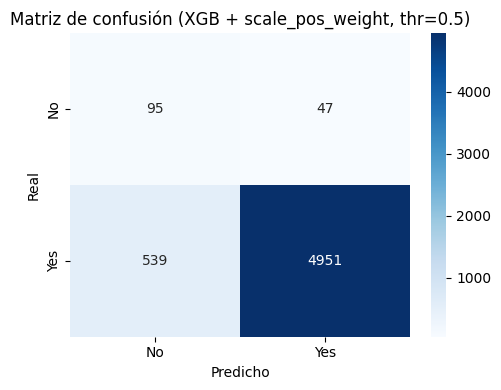

In [24]:
res = entrenar_xgb_weight_timely(dt_quejas, threshold=0.5)


Los resultados del modelo con XGBoost y ajuste de pesos (scale_pos_weight) muestran un desempeño particular en la clase minoritaria (“No”). El modelo logró un recall de 0.67, lo que significa que consiguió identificar alrededor de dos tercios de los casos de retraso, algo mucho mejor que lo alcanzado en otras configuraciones. Sin embargo, esta ganancia en sensibilidad vino acompañada de un sacrificio en precisión: la precisión para la clase “No” cayó a 0.15, lo que implica que muchos casos que en realidad eran respuestas a tiempo fueron clasificados erróneamente como tardíos.

En términos generales, el modelo alcanzó una accuracy del 89.6% y un F1-macro de 0.59, valores más bajos que los observados en los enfoques con Random Forest o XGBoost combinado con SMOTE.

### Analisis comparativo

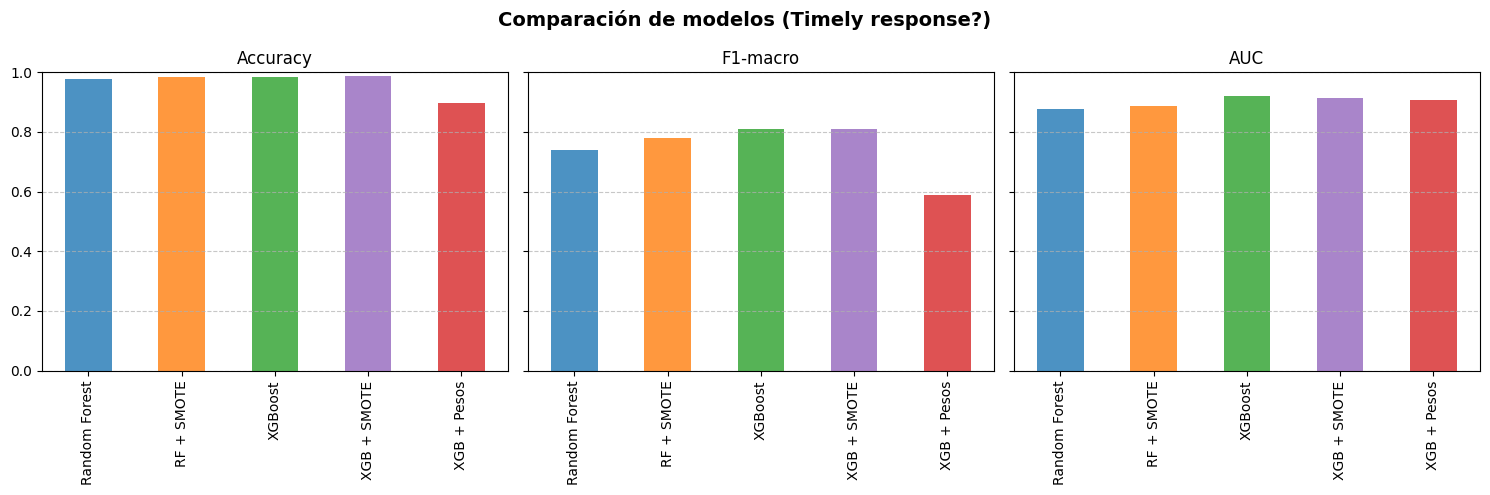

In [26]:
resultados = {
    "Random Forest": {"Accuracy": 0.9767, "F1-macro": 0.74,  "AUC": 0.8765},
    "RF + SMOTE": {"Accuracy": 0.9846, "F1-macro": 0.78,  "AUC": 0.887},
    "XGBoost": {"Accuracy": 0.9858, "F1-macro": 0.81,  "AUC": 0.9201},
    "XGB + SMOTE": {"Accuracy": 0.9865, "F1-macro": 0.81,  "AUC": 0.9156},
    "XGB + Pesos": {"Accuracy": 0.8960, "F1-macro": 0.59,  "AUC": 0.9059}
}

df_resultados = pd.DataFrame(resultados).T
df_resultados = pd.DataFrame(resultados).T

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

metricas = ["Accuracy", "F1-macro", "AUC"]
colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]

for i, metrica in enumerate(metricas):
    df_resultados[metrica].plot(kind="bar", ax=axes[i], color=colores, alpha=0.8)
    axes[i].set_title(metrica)
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Comparación de modelos (Timely response?)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

El rendimiento de los modelos muestra un patrón claro. El Random Forest baseline alcanza una accuracy cercana al 97.7% y un F1-macro de 0.74, con un AUC de 0.88, lo que refleja un buen desempeño general pero con limitaciones en la detección de la clase minoritaria. Al aplicar SMOTE sobre Random Forest, la accuracy sube ligeramente hasta un 98.5% y el F1-macro mejora a 0.78, lo que indica un mejor equilibrio entre clases, aunque el AUC apenas aumenta (0.89).

Por otro lado, el XGBoost baseline es el modelo más sólido: mantiene una accuracy muy alta (98.6%), un F1-macro de 0.81 y, sobre todo, un AUC de 0.92, lo que lo convierte en el mejor discriminador entre respuestas puntuales y retrasos. Con XGBoost + SMOTE, los resultados se mantienen prácticamente iguales: accuracy de 98.6%, F1-macro de 0.81 y AUC de 0.916, lo que demuestra que el balanceo apenas aporta mejora adicional a este algoritmo.

El caso del XGBoost con ajuste de pesos es diferente: la accuracy cae a un 89.6% y el F1-macro baja a 0.59, debido al fuerte incremento de falsos positivos. Sin embargo, mantiene un AUC de 0.91, lo que significa que sigue diferenciando bien entre clases. Su mayor ventaja es que aumenta la sensibilidad hacia la clase minoritaria (“No”), aunque sea a costa de la precisión global.

En conjunto, si buscamos el modelo más robusto y equilibrado, la mejor elección es XGBoost baseline, ya que combina el mayor F1-macro y AUC con una accuracy excelente. No obstante, si el objetivo fuese priorizar la detección de retrasos por encima de la precisión, entonces tendría sentido considerar el ajuste de pesos.